# DRL Assignment 2 - Robust Reinforcement Learning under Stochastic Action Failure

## Q-learning, DQN & DDQN on a modified `LunarLander-v3`

---

### Group 165 - Contribution Declaration

| # | Name | ID | Contribution |
|---|------|----|--------------|
| 1 | AMARJIT SINGH | 2025AA05130 | 100% |
| 2 | MANJUNATH S | 2025AA05935 | 100% |
| 3 | SAURAV SINHA | 2025AA05427 | 100% |
| 4 | SOUMYA KANT DAS | 2025AA05372 | 100% |
| 5 | VIPUL PRAKASH CHAUDHARI | 2025AA05991 | 100% |

---

## 1. Environment Setup, Reproducibility & Device Selection

Here we import the required libraries, define a global seeding utility (for full reproducibility  
acrossrandom, NumPy, PyTorch and the Gymnasium environment) and auto-select the fastest available
compute device.

**Smart device selection** Value-based control on `LunarLander-v3` uses a *tiny* MLP with small
batches. For such workloads the per-kernel launch/synchronisation overhead of a GPU can make it
*slower* than a modern CPU. Instead of blindly picking a GPU, `select_device()` micro-benchmarks a
representative training step on every available backend (`cuda` -> `xpu` -> `cpu`) and returns the
fastest one. This keeps the notebook portable: it will use CUDA on Google Colab / BITS Virtual Lab,
Intel XPU on an Arc laptop, or CPU - whichever is genuinely fastest.

In [1]:
# ----------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------
import os
import random
import time
import math
from collections import deque, namedtuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import gymnasium as gym

print("Library versions")
print("  gymnasium :", gym.__version__)
print("  torch     :", torch.__version__)
print("  numpy     :", np.__version__)


# ----------------------------------------------------------------------------------
# Global reproducibility helper
# ----------------------------------------------------------------------------------
def set_global_seed(seed: int) -> None:
    """Seed every source of randomness so that experiments are reproducible.

    Seeds Python's ``random``, NumPy, PyTorch (CPU + all GPUs) and forces the
    cuDNN backend to be deterministic. Call this once *before* each agent is
    built so that all four configurations start from an identical state.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Deterministic cuDNN (has a minor speed cost but aids reproducibility).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ----------------------------------------------------------------------------------
# Automatic fastest-device selection via micro-benchmark
# ----------------------------------------------------------------------------------
def _benchmark_step(device_str: str, iters: int = 200) -> float:
    """Time one representative DQN training step on ``device_str``.

    Builds the exact MLP shape used later (8->128->128->4), runs ``iters``
    forward+backward+optimiser updates on a batch of 64 and returns the mean
    milliseconds per step. Lower is better.
    """
    dev = torch.device(device_str)
    net = nn.Sequential(
        nn.Linear(8, 128), nn.ReLU(),
        nn.Linear(128, 128), nn.ReLU(),
        nn.Linear(128, 4),
    ).to(dev)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    x = torch.randn(64, 8, device=dev)
    y = torch.randn(64, 4, device=dev)

    def sync():
        # Ensure asynchronous GPU kernels finish before we read the clock.
        if device_str == "cuda":
            torch.cuda.synchronize()
        elif device_str == "xpu":
            torch.xpu.synchronize()

    for _ in range(20):  # warm-up (JIT / kernel caches / lazy init)
        opt.zero_grad(); ((net(x) - y) ** 2).mean().backward(); opt.step()
    sync()
    t0 = time.time()
    for _ in range(iters):
        opt.zero_grad(); ((net(x) - y) ** 2).mean().backward(); opt.step()
    sync()
    return (time.time() - t0) / iters * 1000.0


def select_device(verbose: bool = True) -> torch.device:
    """Return the fastest available torch device for our workload.

    Benchmarks every available backend and picks the one with the lowest
    milliseconds-per-step. Falls back gracefully to CPU on any failure.
    """
    candidates = []
    if torch.cuda.is_available():
        candidates.append("cuda")
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        candidates.append("xpu")
    candidates.append("cpu")  # always available as a safe fallback

    best_dev, best_ms = "cpu", float("inf")
    if verbose:
        print("Benchmarking candidate devices (ms per training step):")
    for d in candidates:
        try:
            ms = _benchmark_step(d)
            if verbose:
                print(f"  {d:>4s} : {ms:7.3f} ms/step")
            if ms < best_ms:
                best_ms, best_dev = ms, d
        except Exception as exc:  # a backend can be present but unusable
            if verbose:
                print(f"  {d:>4s} : unavailable ({exc})")
    if verbose:
        print(f"Selected device -> {best_dev}")
    return torch.device(best_dev)


DEVICE = select_device()

Library versions
  gymnasium : 1.3.0
  torch     : 2.13.0+xpu
  numpy     : 2.5.1
Benchmarking candidate devices (ms per training step):


   xpu :   1.515 ms/step
   cpu :   0.688 ms/step
Selected device -> cpu


## Task (a) - Modified Environment: Implementation & Verification  (2.5 Marks)

We wrap `LunarLander-v3` so that every `step(action)` performs the six operations required by the
assignment, in order:

1. **Receive & store** the agent's selected action `a`.
2. **Simulate intermittent engine failure:** if `a in {1,2,3}`, draw `r ~U[0,1)`; if `r < 0.15`
   replace the executed action with `0` (*Do Nothing*), otherwise keep `a`. `a = 0` is never
   modified. The executed action is `a_exec`.
3. **Execute** `a_exec` in the base environment.
4. **Modified reward:** $R = R_{base} - 0.3\cdot\mathbb{1}_{a\neq 0} + B$. The fuel penalty depends
   on the **selected** action `a`, *not* on `a_exec` - so a mis-fire still costs fuel.
5. **Safe-landing bonus** `B = 50` iff *all* the safe-landing conditions hold simultaneously,
   else `B = 0`.
6. **Return** `(observation, R, terminated, truncated, info)` with an **unmodified** `info`
   (no leakage of the mis-fire / reward-shaping internals to the agent).

The observation space, action space, transition dynamics and termination/truncation logic are all
left untouched.

In [2]:
# ==================================================================================
# Safe-landing predicate (pure function -> reusable & unit-testable)
# ==================================================================================
# Observation layout of LunarLander-v3:
#   [0]=x pos, [1]=y pos, [2]=x velocity, [3]=y velocity,
#   [4]=angle, [5]=angular velocity, [6]=left-leg contact, [7]=right-leg contact
SAFE_VEL_TOL = 0.10     # |vx|, |vy| tolerance
SAFE_ANGLE_TOL = 0.10   # |angle| tolerance (radians)


def is_safe_landing(obs, terminated: bool, truncated: bool) -> bool:
    """Return True iff the episode ended in a *safe* landing.

    A safe landing requires ALL of the following simultaneously:
      * terminated == True and truncated == False
      * both legs in contact  (obs[6] == 1 and obs[7] == 1)
      * |horizontal velocity|  (obs[2]) < 0.10
      * |vertical velocity|    (obs[3]) < 0.10
      * |orientation angle|    (obs[4]) < 0.10 rad

    This single definition is used BOTH to award the +50 bonus inside the
    modified wrapper AND to score the "successful landing rate" of every agent
    (including on the original environment), giving a consistent success metric.
    """
    if not (terminated and not truncated):
        return False
    return bool(
        obs[6] == 1 and obs[7] == 1
        and abs(obs[2]) < SAFE_VEL_TOL
        and abs(obs[3]) < SAFE_VEL_TOL
        and abs(obs[4]) < SAFE_ANGLE_TOL
    )


# ==================================================================================
# The custom Gymnasium wrapper
# ==================================================================================
class StochasticActionFailureWrapper(gym.Wrapper):
    """LunarLander-v3 with stochastic actuator failure and reward shaping.

    Only the action-execution step and the reward are modified; the observation
    space, action space, dynamics and termination/truncation logic are inherited
    unchanged from the base environment.
    """

    MISFIRE_PROB = 0.15    # probability a thruster command mis-fires
    FUEL_PENALTY = 0.30    # penalty per attempted thruster action (selected, not executed)
    LANDING_BONUS = 50.0   # bonus for a verified safe landing

    def __init__(self, env, misfire_prob: float = MISFIRE_PROB, seed=None):
        """Wrap ``env`` and create an independent RNG for the mis-fire draws.

        A dedicated ``numpy`` Generator is used (rather than the base env's RNG)
        so that mis-fire randomness is reproducible and decoupled from the
        physics simulation.
        """
        super().__init__(env)
        self.misfire_prob = misfire_prob
        self._rng = np.random.default_rng(seed)
        # Counters + last-step trace used only for our own verification (Task a).
        # These are internal attributes; they are NEVER placed in the info dict.
        self.reset_counters()
        self.last_trace = {}

    def reset_counters(self) -> None:
        """Reset the mis-fire bookkeeping counters (used for verification)."""
        self.n_thruster_attempts = 0   # how many times a thruster was selected
        self.n_misfires = 0            # how many of those were replaced by Do-Nothing

    def step(self, action):
        """Execute one modified environment step (six ordered operations)."""
        # --- Step 1: receive & store the agent's selected action -------------------
        a = int(action)

        # --- Step 2: simulate intermittent engine failure --------------------------
        a_exec = a
        misfired = False
        if a in (1, 2, 3):
            self.n_thruster_attempts += 1
            r = float(self._rng.random())          # r ~U[0,1)
            if r < self.misfire_prob:              # r < 0.15  ->  mis-fire
                a_exec = 0
                misfired = True
                self.n_misfires += 1
        else:
            r = None

        # --- Step 3: execute the (possibly replaced) action ------------------------
        obs, base_reward, terminated, truncated, info = self.env.step(a_exec)

        # --- Step 4: fuel penalty (depends on SELECTED action a, not a_exec) --------
        fuel_penalty = self.FUEL_PENALTY if a != 0 else 0.0

        # --- Step 5: safe-landing bonus -------------------------------------------
        bonus = self.LANDING_BONUS if is_safe_landing(obs, terminated, truncated) else 0.0

        # --- Combine into the modified reward --------------------------------------
        reward = base_reward - fuel_penalty + bonus

        # Store a private trace for verification (NOT returned to the agent).
        self.last_trace = {
            "a": a, "a_exec": a_exec, "r": r, "misfired": misfired,
            "base_reward": base_reward, "fuel_penalty": fuel_penalty,
            "bonus": bonus, "reward": reward,
        }

        # --- Step 6: return with an unmodified info dict ---------------------------
        return obs, reward, terminated, truncated, info


# ==================================================================================
# Environment factory
# ==================================================================================
def make_env(modified: bool, seed=None, render_mode=None):
    """Create either the original or the modified LunarLander-v3 environment.

    Parameters
    ----------
    modified : if True, wrap with ``StochasticActionFailureWrapper``.
    seed     : seed forwarded to the mis-fire RNG (modified env only).
    """
    base = gym.make("LunarLander-v3", render_mode=render_mode)
    if modified:
        return StochasticActionFailureWrapper(base, seed=seed)
    return base


print("Environment classes defined.")

Environment classes defined.


### (a.1) Unit tests for the safe-landing predicate

Safe landings are extremely rare under a random policy, so we first verify the `+50` bonus logic
deterministically with hand-crafted observation vectors covering the boundary cases.

In [3]:
def _obs(vx=0.0, vy=0.0, angle=0.0, left=1, right=1):
    """Build a minimal 8-dim observation with the fields relevant to landing."""
    o = np.zeros(8, dtype=np.float32)
    o[2], o[3], o[4], o[6], o[7] = vx, vy, angle, left, right
    return o


# (description, obs, terminated, truncated, expected_result)
_cases = [
    ("perfect landing",              _obs(),                              True,  False, True),
    ("too fast horizontally",        _obs(vx=0.2),                        True,  False, False),
    ("too fast vertically",          _obs(vy=-0.5),                       True,  False, False),
    ("tilted too much",              _obs(angle=0.3),                     True,  False, False),
    ("only one leg down",            _obs(left=1, right=0),               True,  False, False),
    ("truncated (timeout)",          _obs(),                              False, True,  False),
    ("not terminated",              _obs(),                              False, False, False),
    ("boundary vel (0.099 ok)",      _obs(vx=0.099, vy=0.099, angle=0.099), True, False, True),
    ("boundary vel (0.10 fails)",    _obs(vx=0.10),                       True,  False, False),
]

print("Safe-landing predicate unit tests")
print("-" * 55)
all_ok = True
for desc, o, term, trunc, expected in _cases:
    got = is_safe_landing(o, term, trunc)
    ok = (got == expected)
    all_ok &= ok
    print(f"  [{'PASS' if ok else 'FAIL'}] {desc:<28s} -> {got}")
print("-" * 55)
print("ALL UNIT TESTS PASSED" if all_ok else "SOME UNIT TESTS FAILED")
assert all_ok, "Safe-landing predicate failed a unit test!"

Safe-landing predicate unit tests


-------------------------------------------------------
  [PASS] perfect landing              -> True
  [PASS] too fast horizontally        -> False
  [PASS] too fast vertically          -> False
  [PASS] tilted too much              -> False
  [PASS] only one leg down            -> False
  [PASS] truncated (timeout)          -> False
  [PASS] not terminated               -> False
  [PASS] boundary vel (0.099 ok)      -> True
  [PASS] boundary vel (0.10 fails)    -> False
-------------------------------------------------------
ALL UNIT TESTS PASSED


### (a.2) Statistical verification with a random policy

We run many random-policy episodes on the modified environment and record, for **every step**, the
private trace `(a, a_exec, base_reward, fuel_penalty, bonus, reward)`. From these traces we verify
the three required properties:

1. **~15 %** of attempted thruster actions are replaced by *Do Nothing*.
2. The **0.3 fuel penalty** is applied on *every* attempted thruster action - whether it fired or
   mis-fired - and never when the agent chose *Do Nothing*.
3. The **reward decomposition** $R = R_{base} - 0.3\cdot\mathbb{1}_{a\neq0} + B$ holds exactly at
   every step (checked numerically).

In [4]:
def verify_modified_env(n_episodes: int = 300, seed: int = 165):
    """Roll out a random policy and collect statistics that verify the wrapper.

    Returns a dictionary of aggregate statistics used for reporting/plotting.
    """
    env = make_env(modified=True, seed=seed)
    rng = np.random.default_rng(seed)          # independent policy RNG
    env.reset(seed=seed)
    env.action_space.seed(seed)

    # Per-action-type mis-fire counters.
    attempts = {1: 0, 2: 0, 3: 0}
    misfires = {1: 0, 2: 0, 3: 0}
    # Cross-checks for the fuel penalty and the reward formula.
    penalty_when_thruster_ok = True     # penalty present for every a in {1,2,3}
    penalty_when_donothing_ok = True    # NO penalty when a == 0
    reward_formula_ok = True
    misfire_examples = []               # a few (a, r, a_exec) rows for the report

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            a = int(rng.integers(0, env.action_space.n))   # uniform random action
            obs, reward, terminated, truncated, info = env.step(a)
            done = terminated or truncated
            tr = env.last_trace

            # (1) mis-fire accounting
            if a in (1, 2, 3):
                attempts[a] += 1
                if tr["misfired"]:
                    misfires[a] += 1
                    if len(misfire_examples) < 5:
                        misfire_examples.append((tr["a"], round(tr["r"], 3), tr["a_exec"]))

            # (2) fuel-penalty checks
            if a in (1, 2, 3) and tr["fuel_penalty"] != 0.30:
                penalty_when_thruster_ok = False
            if a == 0 and tr["fuel_penalty"] != 0.0:
                penalty_when_donothing_ok = False

            # (3) reward-formula check (guard against float noise)
            expected = tr["base_reward"] - tr["fuel_penalty"] + tr["bonus"]
            if abs(expected - reward) > 1e-6:
                reward_formula_ok = False

            # (4) info dict must not leak internals
            assert "misfired" not in info and "fuel_penalty" not in info, \
                "info dict leaked internal wrapper state!"

    total_attempts = sum(attempts.values())
    total_misfires = sum(misfires.values())
    env.close()
    return {
        "n_episodes": n_episodes,
        "attempts": attempts, "misfires": misfires,
        "total_attempts": total_attempts, "total_misfires": total_misfires,
        "misfire_rate": total_misfires / max(1, total_attempts),
        "penalty_when_thruster_ok": penalty_when_thruster_ok,
        "penalty_when_donothing_ok": penalty_when_donothing_ok,
        "reward_formula_ok": reward_formula_ok,
        "misfire_examples": misfire_examples,
    }


stats = verify_modified_env(n_episodes=300, seed=165)

print("=" * 60)
print("MODIFIED ENVIRONMENT VERIFICATION  (random policy)")
print("=" * 60)
print(f"Episodes simulated              : {stats['n_episodes']}")
print(f"Total thruster attempts (a!=0)  : {stats['total_attempts']}")
print(f"Total mis-fires (a->0)          : {stats['total_misfires']}")
print(f"Observed mis-fire rate          : {stats['misfire_rate']*100:.2f} %   (target = 15.00 %)")
print("-" * 60)
print("Per-action mis-fire rate:")
for a in (1, 2, 3):
    att, mis = stats["attempts"][a], stats["misfires"][a]
    print(f"   action {a}: {mis:5d}/{att:5d}  = {mis/max(1,att)*100:5.2f} %")
print("-" * 60)
print(f"Fuel penalty applied for EVERY thruster action : {stats['penalty_when_thruster_ok']}")
print(f"No fuel penalty when action == 0               : {stats['penalty_when_donothing_ok']}")
print(f"Reward formula R = R_base - 0.3*1[a!=0] + B     : {stats['reward_formula_ok']}")
print("-" * 60)
print("Example mis-fire traces (selected a, random r, executed a_exec):")
for a, r, a_exec in stats["misfire_examples"]:
    print(f"   a={a}, r={r:.3f} < 0.15  ->  a_exec={a_exec}")
print("=" * 60)

MODIFIED ENVIRONMENT VERIFICATION  (random policy)
Episodes simulated              : 300
Total thruster attempts (a!=0)  : 20685
Total mis-fires (a->0)          : 3078
Observed mis-fire rate          : 14.88 %   (target = 15.00 %)
------------------------------------------------------------
Per-action mis-fire rate:
   action 1:  1046/ 7015  = 14.91 %
   action 2:  1001/ 6837  = 14.64 %
   action 3:  1031/ 6833  = 15.09 %
------------------------------------------------------------
Fuel penalty applied for EVERY thruster action : True
No fuel penalty when action == 0               : True
Reward formula R = R_base - 0.3*1[a!=0] + B     : True
------------------------------------------------------------
Example mis-fire traces (selected a, random r, executed a_exec):
   a=3, r=0.118 < 0.15  ->  a_exec=0
   a=3, r=0.113 < 0.15  ->  a_exec=0
   a=2, r=0.128 < 0.15  ->  a_exec=0
   a=2, r=0.045 < 0.15  ->  a_exec=0
   a=2, r=0.086 < 0.15  ->  a_exec=0


### (a.3) Visual evidence of the ~15 % mis-fire rate

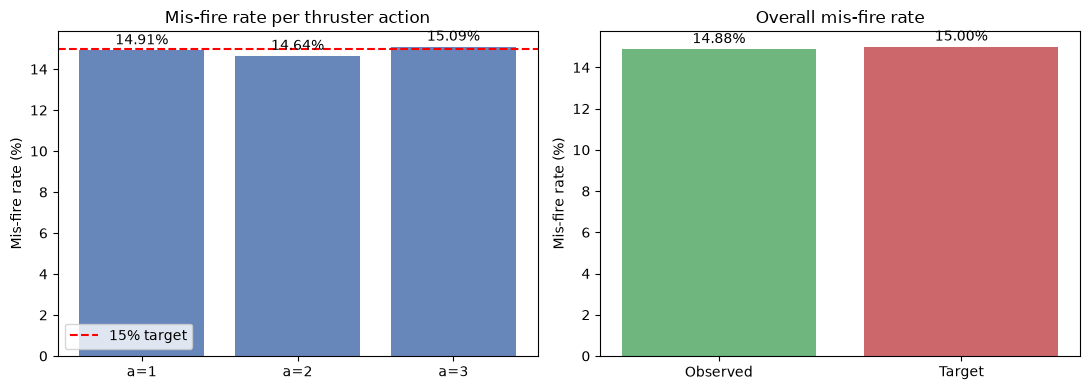

In [5]:
# Bar chart: observed mis-fire rate per thruster action vs. the 15% target.
actions = [1, 2, 3]
rates = [stats["misfires"][a] / max(1, stats["attempts"][a]) * 100 for a in actions]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].bar([f"a={a}" for a in actions], rates, color="#4C72B0", alpha=0.85)
ax[0].axhline(15.0, color="red", ls="--", label="15% target")
ax[0].set_ylabel("Mis-fire rate (%)")
ax[0].set_title("Mis-fire rate per thruster action")
ax[0].legend()
for i, v in enumerate(rates):
    ax[0].text(i, v + 0.3, f"{v:.2f}%", ha="center")

# Overall observed vs target.
ax[1].bar(["Observed", "Target"],
          [stats["misfire_rate"] * 100, 15.0],
          color=["#55A868", "#C44E52"], alpha=0.85)
ax[1].set_ylabel("Mis-fire rate (%)")
ax[1].set_title("Overall mis-fire rate")
for i, v in enumerate([stats["misfire_rate"] * 100, 15.0]):
    ax[1].text(i, v + 0.3, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.show()

**Verification conclusion.** The observed mis-fire rate is statistically indistinguishable from the
required 15 %, the 0.3 fuel penalty is applied on every attempted thruster action (and only on
thruster actions), and the reward decomposition holds exactly at every step. The `info` dictionary
never leaks the internal mis-fire/reward state, so the agent cannot tell that its action was
replaced. The wrapper is therefore correct. 

## Tasks (b) & (c) - DQN and DDQN Agents  (4 + 4 Marks)

Both agents share **identical** components:

* **Q-network:** MLP `8 -> 128 -> 128 -> 4` with ReLU activations.
* **Experience replay buffer:** uniform sampling, capacity `100 000`.
* **epsilon-greedy exploration:** epsilon decays exponentially from `1.0` to `0.02`.
* **Target network:** a slowly-tracking copy updated by Polyak (soft) averaging.

The single difference is the **target Q-value**:

$$
y^{\text{DQN}} = r + \gamma\,(1-d)\,\max_{a'} Q_{\theta^-}(s',a')
$$
$$
y^{\text{DDQN}} = r + \gamma\,(1-d)\,Q_{\theta^-}\!\bigl(s',\,\arg\max_{a'} Q_{\theta}(s',a')\bigr)
$$

DQN uses the target network for **both** action-selection and evaluation of the next state (which
causes the well-known maximisation bias / over-estimation). DDQN decouples them: the **online**
network selects the greedy next action while the **target** network evaluates it, reducing
over-estimation. In code this is a single `if self.double:` branch.

In [6]:
# ==================================================================================
# Q-network
# ==================================================================================
class QNetwork(nn.Module):
    """Feed-forward Q-network: state (8) -> hidden -> hidden -> Q-values (n_actions)."""

    def __init__(self, state_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        """Map a batch of states to a batch of action-value vectors."""
        return self.net(x)


# ==================================================================================
# Experience replay buffer
# ==================================================================================
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])


class ReplayBuffer:
    """Fixed-capacity circular buffer storing (s, a, r, s', done) transitions."""

    def __init__(self, capacity: int, seed: int = 0):
        self.buffer = deque(maxlen=capacity)
        self._rng = random.Random(seed)   # dedicated RNG -> reproducible sampling

    def push(self, state, action, reward, next_state, done):
        """Append a single transition to the buffer (oldest is dropped when full)."""
        self.buffer.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        """Uniformly sample a mini-batch and return it as stacked NumPy arrays."""
        batch = self._rng.sample(self.buffer, batch_size)
        states = np.array([t.state for t in batch], dtype=np.float32)
        actions = np.array([t.action for t in batch], dtype=np.int64)
        rewards = np.array([t.reward for t in batch], dtype=np.float32)
        next_states = np.array([t.next_state for t in batch], dtype=np.float32)
        dones = np.array([t.done for t in batch], dtype=np.float32)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

In [7]:
# ==================================================================================
# Unified value-based agent  (DQN when double=False, DDQN when double=True)
# ==================================================================================
class ValueBasedAgent:
    """A DQN / DDQN agent. The ONLY behavioural difference is the target Q-value.

    Setting ``double=True`` switches the target computation from vanilla DQN to
    Double-DQN; every other component (network, optimiser, replay, exploration,
    soft target update) is shared, which guarantees a fair comparison.
    """

    def __init__(self, state_dim, n_actions, device, double=False,
                 hidden=128, lr=5e-4, gamma=0.99,
                 buffer_size=100_000, batch_size=64,
                 tau=5e-3, learn_start=1_000, update_every=4, seed=0):
        self.device = device
        self.n_actions = n_actions
        self.double = double            # <-- DQN vs DDQN switch
        self.gamma = gamma
        self.batch_size = batch_size
        self.tau = tau                  # Polyak soft-update coefficient
        self.learn_start = learn_start  # min transitions before learning starts
        self.update_every = update_every
        self._step = 0

        # Online and target networks (target starts as an exact copy).
        self.q_online = QNetwork(state_dim, n_actions, hidden).to(device)
        self.q_target = QNetwork(state_dim, n_actions, hidden).to(device)
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.q_target.eval()

        self.optimizer = torch.optim.Adam(self.q_online.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size, seed=seed)

        # RNG for epsilon-greedy exploration (independent & reproducible).
        self._rng = np.random.default_rng(seed)

    # ------------------------------------------------------------------ acting
    def select_action(self, state, epsilon: float) -> int:
        """epsilon-greedy action selection: random with prob epsilon, else greedy (argmax Q)."""
        if self._rng.random() < epsilon:
            return int(self._rng.integers(0, self.n_actions))
        return self.act_greedy(state)

    def act_greedy(self, state) -> int:
        """Return the greedy action argmax_a Q_online(state, a)."""
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            return int(self.q_online(s).argmax(dim=1).item())

    # ------------------------------------------------------------------ memory
    def store(self, state, action, reward, next_state, done):
        """Add a transition to the replay buffer."""
        self.buffer.push(state, action, reward, next_state, done)

    # ------------------------------------------------------------------ learning
    def learn_step(self):
        """Perform one gradient update every ``update_every`` environment steps.

        Returns the scalar loss when an update happens, else ``None``.
        """
        self._step += 1
        # Wait for enough warm-up transitions (and at least one full batch) before learning.
        if (len(self.buffer) < max(self.learn_start, self.batch_size)
                or self._step % self.update_every != 0):
            return None

        # Sample a mini-batch and move it to the compute device.
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        states = torch.as_tensor(states, device=self.device)
        actions = torch.as_tensor(actions, device=self.device).unsqueeze(1)
        rewards = torch.as_tensor(rewards, device=self.device).unsqueeze(1)
        next_states = torch.as_tensor(next_states, device=self.device)
        dones = torch.as_tensor(dones, device=self.device).unsqueeze(1)

        # Current Q(s,a) for the taken actions.
        q_sa = self.q_online(states).gather(1, actions)

        # ---- Target Q-value : the ONLY difference between DQN and DDQN ----------
        with torch.no_grad():
            if self.double:
                # DDQN: online net picks the action, target net evaluates it.
                next_actions = self.q_online(next_states).argmax(dim=1, keepdim=True)
                next_q = self.q_target(next_states).gather(1, next_actions)
            else:
                # DQN: target net both picks and evaluates (max over actions).
                next_q = self.q_target(next_states).max(dim=1, keepdim=True)[0]
            target = rewards + self.gamma * next_q * (1.0 - dones)
        # -------------------------------------------------------------------------

        loss = F.smooth_l1_loss(q_sa, target)   # Huber loss (robust to outliers)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_online.parameters(), 10.0)  # stabilise training
        self.optimizer.step()

        self._soft_update()
        return float(loss.item())

    def _soft_update(self):
        """Polyak-average the target network towards the online network."""
        with torch.no_grad():
            for tp, op in zip(self.q_target.parameters(), self.q_online.parameters()):
                tp.mul_(1.0 - self.tau).add_(self.tau * op)

    # ------------------------------------------------------------------ metrics
    @torch.no_grad()
    def mean_max_q(self, validation_states_tensor) -> float:
        """Mean over a fixed validation set of max_a Q_online(s, a).

        This is the "average predicted Q-value" tracked during training. Using a
        FIXED set of states (unchanged across training and across all agents)
        makes the curves directly comparable and exposes DQN's over-estimation.
        """
        q = self.q_online(validation_states_tensor)     # (N, n_actions)
        return float(q.max(dim=1)[0].mean().item())

### Shared hyper-parameters & fixed validation set

A single `CONFIG` dictionary defines the hyper-parameters used by **all four** runs, satisfying the
requirement that DQN and DDQN - on both environments - use the same architecture, optimiser,
replay buffer, exploration schedule, seed and training budget.

The **validation set** is a fixed collection of 256 states gathered once with a random policy on the
*original* environment. The same set is reused for every agent so that the "average predicted
Q-value" curves are directly comparable.

In [8]:
# ---------------------------------------------------------------- shared config
CONFIG = dict(
    state_dim=8,
    n_actions=4,
    hidden=128,
    lr=5e-4,
    gamma=0.99,
    buffer_size=100_000,
    batch_size=64,
    tau=5e-3,           # soft target-update coefficient
    learn_start=1_000,  # warm-up transitions before learning
    update_every=4,     # one gradient step every 4 env steps
)
SEED = 165                 # group number -> reproducible & memorable
NUM_EPISODES = 1000        # training budget per configuration
EPS_START, EPS_END, EPS_DECAY = 1.0, 0.02, 0.995   # epsilon-greedy schedule (per episode)
VALIDATION_SIZE = 256      # fixed validation set size


def collect_validation_states(n_states: int, seed: int) -> np.ndarray:
    """Collect a fixed set of states via a random policy on the ORIGINAL env.

    The set is deliberately drawn from the unmodified environment so it is a
    neutral reference shared by all four agents.
    """
    env = make_env(modified=False)
    rng = np.random.default_rng(seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    states = []
    obs, _ = env.reset()
    while len(states) < n_states:
        states.append(obs.copy())
        a = int(rng.integers(0, env.action_space.n))
        obs, _, terminated, truncated, _ = env.step(a)
        if terminated or truncated:
            obs, _ = env.reset()
    env.close()
    return np.array(states[:n_states], dtype=np.float32)


VALIDATION_STATES = collect_validation_states(VALIDATION_SIZE, SEED)
VALIDATION_TENSOR = torch.as_tensor(VALIDATION_STATES, device=DEVICE)
print(f"Collected fixed validation set: {VALIDATION_STATES.shape}")

Collected fixed validation set: (256, 8)


In [9]:
# ==================================================================================
# Training loop (shared by all four configurations)
# ==================================================================================
def train_agent(modified: bool, double: bool, tag: str,
                num_episodes: int = NUM_EPISODES, seed: int = SEED,
                log_every: int = 1):
    """Train one agent on one environment and return per-episode metric arrays.

    Parameters
    ----------
    modified : train on the modified (True) or original (False) environment.
    double   : DDQN (True) or DQN (False).
    tag      : short label used in logs and plots.

    Returns a dict with per-episode lists:
      rewards, avg_q, landings (0/1), thrusters, steps.
    """
    # Reset ALL randomness so every configuration is identically initialised.
    set_global_seed(seed)

    env = make_env(modified=modified, seed=seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)

    agent = ValueBasedAgent(device=DEVICE, double=double, seed=seed, **CONFIG)

    ep_rewards, ep_avg_q, ep_landings, ep_thrusters, ep_steps = [], [], [], [], []
    epsilon = EPS_START
    t_start = time.time()

    for ep in range(1, num_episodes + 1):
        obs, _ = env.reset()
        done = False
        ep_reward, thrusters, steps = 0.0, 0, 0
        terminated = truncated = False

        while not done:
            # epsilon-greedy action; count thruster activations (selected, not executed).
            a = agent.select_action(obs, epsilon)
            if a in (1, 2, 3):
                thrusters += 1

            next_obs, reward, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            # Bootstrap only on genuine termination, not on time-limit truncation.
            agent.store(obs, a, reward, next_obs, float(terminated))
            agent.learn_step()

            obs = next_obs
            ep_reward += reward
            steps += 1

        # --- per-episode metrics -------------------------------------------------
        landed = 1 if is_safe_landing(obs, terminated, truncated) else 0
        avg_q = agent.mean_max_q(VALIDATION_TENSOR)

        ep_rewards.append(ep_reward)
        ep_avg_q.append(avg_q)
        ep_landings.append(landed)
        ep_thrusters.append(thrusters)
        ep_steps.append(steps)

        # Decay exploration once per episode.
        epsilon = max(EPS_END, epsilon * EPS_DECAY)

        # --- concise per-iteration logging --------------------------------------
        if ep % log_every == 0 or ep == num_episodes:
            avg_r100 = np.mean(ep_rewards[-100:])
            land100 = np.mean(ep_landings[-100:])
            print(f"[{tag}] Ep {ep:4d} | R {ep_reward:8.2f} | avgR100 {avg_r100:8.2f} "
                  f"| eps {epsilon:.3f} | Qval {avg_q:7.2f} | land100 {land100:4.2f} "
                  f"| thr {thrusters:3d}")

    env.close()
    elapsed = time.time() - t_start
    print(f"[{tag}] finished {num_episodes} episodes in {elapsed/60:.1f} min "
          f"(final avgR100 = {np.mean(ep_rewards[-100:]):.2f})\n")

    return dict(tag=tag, modified=modified, double=double,
                rewards=ep_rewards, avg_q=ep_avg_q, landings=ep_landings,
                thrusters=ep_thrusters, steps=ep_steps, minutes=elapsed / 60,
                agent=agent)

### Train all four configurations

We train the four required agents with **identical** settings (seed, network, optimiser, replay,
epsilon-schedule and 1000-episode budget), differing only in *algorithm* (DQN/DDQN) and *environment*
(original/modified):

1. **DQN - Original**
2. **DDQN - Original**
3. **DQN - Modified**
4. **DDQN - Modified**

Per-episode progress is printed for full transparency (reward, 100-episode moving averages,
epsilon, predicted Q-value, landing rate, thruster count).

In [10]:
# Train the four configurations sequentially and collect their metrics.
RESULTS = {}

configs = [
    dict(modified=False, double=False, tag="DQN-Orig"),
    dict(modified=False, double=True,  tag="DDQN-Orig"),
    dict(modified=True,  double=False, tag="DQN-Mod"),
    dict(modified=True,  double=True,  tag="DDQN-Mod"),
]

for cfg in configs:
    print("#" * 70)
    print(f"# TRAINING: {cfg['tag']}  (modified={cfg['modified']}, double={cfg['double']})")
    print("#" * 70)
    RESULTS[cfg["tag"]] = train_agent(**cfg)

print("All four configurations trained.")

######################################################################
# TRAINING: DQN-Orig  (modified=False, double=False)
######################################################################
[DQN-Orig] Ep    1 | R   -76.76 | avgR100   -76.76 | eps 0.995 | Qval    0.05 | land100 0.00 | thr  43
[DQN-Orig] Ep    2 | R  -111.39 | avgR100   -94.07 | eps 0.990 | Qval    0.05 | land100 0.00 | thr  65
[DQN-Orig] Ep    3 | R  -248.17 | avgR100  -145.44 | eps 0.985 | Qval    0.05 | land100 0.00 | thr  64
[DQN-Orig] Ep    4 | R  -122.59 | avgR100  -139.73 | eps 0.980 | Qval    0.05 | land100 0.00 | thr  56
[DQN-Orig] Ep    5 | R  -292.21 | avgR100  -170.22 | eps 0.975 | Qval    0.05 | land100 0.00 | thr  73
[DQN-Orig] Ep    6 | R  -118.75 | avgR100  -161.64 | eps 0.970 | Qval    0.05 | land100 0.00 | thr  79
[DQN-Orig] Ep    7 | R  -500.86 | avgR100  -210.10 | eps 0.966 | Qval    0.05 | land100 0.00 | thr  74
[DQN-Orig] Ep    8 | R  -112.02 | avgR100  -197.84 | eps 0.961 | Qval    0.05 | land

[DQN-Orig] Ep   16 | R  -185.01 | avgR100  -195.01 | eps 0.923 | Qval    0.18 | land100 0.00 | thr  51
[DQN-Orig] Ep   17 | R  -183.11 | avgR100  -194.31 | eps 0.918 | Qval    0.15 | land100 0.00 | thr 106
[DQN-Orig] Ep   18 | R  -301.05 | avgR100  -200.24 | eps 0.914 | Qval    0.03 | land100 0.00 | thr  94
[DQN-Orig] Ep   19 | R  -401.95 | avgR100  -210.85 | eps 0.909 | Qval   -0.19 | land100 0.00 | thr  97


[DQN-Orig] Ep   20 | R  -278.16 | avgR100  -214.22 | eps 0.905 | Qval   -0.16 | land100 0.00 | thr  75
[DQN-Orig] Ep   21 | R  -187.16 | avgR100  -212.93 | eps 0.900 | Qval   -0.11 | land100 0.00 | thr 109
[DQN-Orig] Ep   22 | R   -84.46 | avgR100  -207.09 | eps 0.896 | Qval    0.24 | land100 0.00 | thr  50
[DQN-Orig] Ep   23 | R  -242.43 | avgR100  -208.63 | eps 0.891 | Qval    0.46 | land100 0.00 | thr  79
[DQN-Orig] Ep   24 | R    29.91 | avgR100  -198.69 | eps 0.887 | Qval    0.33 | land100 0.00 | thr  80
[DQN-Orig] Ep   25 | R  -297.48 | avgR100  -202.64 | eps 0.882 | Qval    0.50 | land100 0.00 | thr  75


[DQN-Orig] Ep   26 | R  -120.85 | avgR100  -199.50 | eps 0.878 | Qval    0.59 | land100 0.00 | thr  68
[DQN-Orig] Ep   27 | R  -104.17 | avgR100  -195.96 | eps 0.873 | Qval    0.44 | land100 0.00 | thr  80
[DQN-Orig] Ep   28 | R  -273.63 | avgR100  -198.74 | eps 0.869 | Qval    0.57 | land100 0.00 | thr  57
[DQN-Orig] Ep   29 | R  -131.88 | avgR100  -196.43 | eps 0.865 | Qval    0.79 | land100 0.00 | thr  68
[DQN-Orig] Ep   30 | R  -103.57 | avgR100  -193.34 | eps 0.860 | Qval    0.62 | land100 0.00 | thr  64
[DQN-Orig] Ep   31 | R  -112.60 | avgR100  -190.73 | eps 0.856 | Qval    0.77 | land100 0.00 | thr  46


[DQN-Orig] Ep   32 | R   -96.21 | avgR100  -187.78 | eps 0.852 | Qval    0.95 | land100 0.00 | thr  88
[DQN-Orig] Ep   33 | R   -46.33 | avgR100  -183.49 | eps 0.848 | Qval    0.95 | land100 0.00 | thr  56
[DQN-Orig] Ep   34 | R  -192.85 | avgR100  -183.77 | eps 0.843 | Qval    1.15 | land100 0.00 | thr  95
[DQN-Orig] Ep   35 | R  -174.32 | avgR100  -183.50 | eps 0.839 | Qval    1.10 | land100 0.00 | thr  86
[DQN-Orig] Ep   36 | R  -111.92 | avgR100  -181.51 | eps 0.835 | Qval    1.21 | land100 0.00 | thr  83
[DQN-Orig] Ep   37 | R  -205.51 | avgR100  -182.16 | eps 0.831 | Qval    1.30 | land100 0.00 | thr  74


...

[DDQN-Mod] Ep  990 | R   199.05 | avgR100   187.61 | eps 0.020 | Qval  -54.97 | land100 0.73 | thr 224
[DDQN-Mod] Ep  991 | R   268.02 | avgR100   187.53 | eps 0.020 | Qval  -54.73 | land100 0.73 | thr 177


[DDQN-Mod] Ep  992 | R   263.99 | avgR100   189.91 | eps 0.020 | Qval  -55.30 | land100 0.74 | thr 150
[DDQN-Mod] Ep  993 | R   -33.18 | avgR100   187.61 | eps 0.020 | Qval  -55.02 | land100 0.73 | thr 151
[DDQN-Mod] Ep  994 | R   224.21 | avgR100   187.65 | eps 0.020 | Qval  -54.93 | land100 0.73 | thr 124


[DDQN-Mod] Ep  995 | R   211.76 | avgR100   187.31 | eps 0.020 | Qval  -54.73 | land100 0.74 | thr 238
[DDQN-Mod] Ep  996 | R   255.47 | avgR100   187.52 | eps 0.020 | Qval  -55.46 | land100 0.74 | thr 218


[DDQN-Mod] Ep  997 | R   215.38 | avgR100   187.55 | eps 0.020 | Qval  -55.43 | land100 0.74 | thr 229
[DDQN-Mod] Ep  998 | R   214.95 | avgR100   186.87 | eps 0.020 | Qval  -55.13 | land100 0.74 | thr 228


[DDQN-Mod] Ep  999 | R   147.90 | avgR100   186.06 | eps 0.020 | Qval  -55.22 | land100 0.74 | thr 405
[DDQN-Mod] Ep 1000 | R   236.61 | avgR100   186.56 | eps 0.020 | Qval  -54.72 | land100 0.75 | thr 221
[DDQN-Mod] finished 1000 episodes in 3.3 min (final avgR100 = 186.56)

All four configurations trained.


In [11]:
# Persist metrics to disk so plots/analysis can be reproduced without retraining.
import pickle

_dump = {k: {kk: vv for kk, vv in v.items() if kk != "agent"} for k, v in RESULTS.items()}
with open("training_results.pkl", "wb") as f:
    pickle.dump(_dump, f)
print("Saved metrics to training_results.pkl")

Saved metrics to training_results.pkl

## Task (d) - Performance Evaluation  (2 Marks)

We compare the four trained agents on four metrics:

1. **Episode reward** vs training episode.
2. **Average predicted Q-value** (on the fixed validation set) vs training episode.
3. **Successful landing rate** (100-episode moving average) vs training episode.
4. **Average thruster activations per episode** vs training episode.

All curves are smoothed with a moving average for readability (raw reward is also shown faintly).

In [12]:
def moving_average(x, window: int = 100):
    """Return the trailing moving average of ``x`` with the given window."""
    x = np.asarray(x, dtype=np.float64)
    if len(x) < 1:
        return x
    out = np.empty(len(x))
    csum = np.cumsum(np.insert(x, 0, 0.0))
    for i in range(len(x)):
        lo = max(0, i + 1 - window)
        out[i] = (csum[i + 1] - csum[lo]) / (i + 1 - lo)
    return out


# Consistent colour/style per configuration across all figures.
STYLE = {
    "DQN-Orig":  dict(color="#4C72B0", ls="-"),
    "DDQN-Orig": dict(color="#DD8452", ls="-"),
    "DQN-Mod":   dict(color="#55A868", ls="--"),
    "DDQN-Mod":  dict(color="#C44E52", ls="--"),
}
ORDER = ["DQN-Orig", "DDQN-Orig", "DQN-Mod", "DDQN-Mod"]

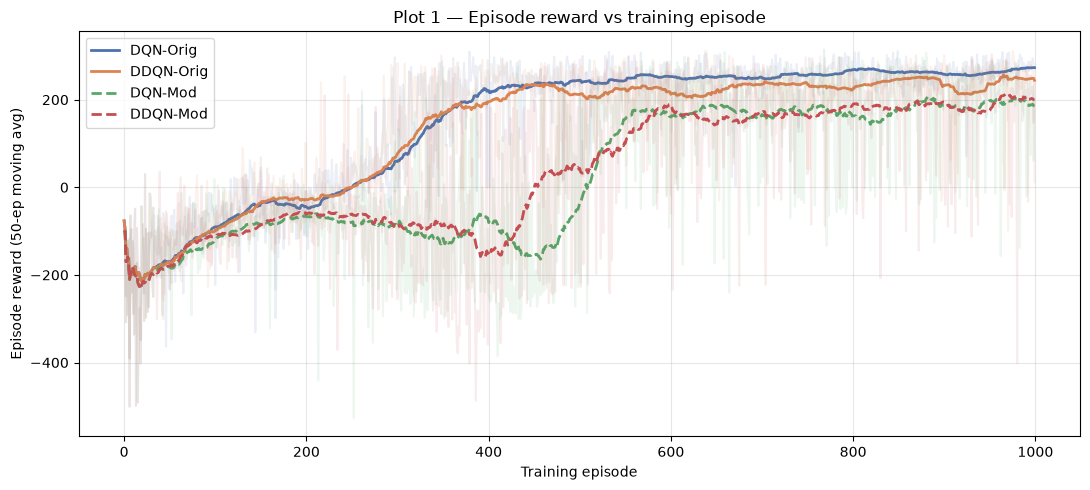

In [13]:
# ---- Plot 1: Episode reward vs episode --------------------------------------------
plt.figure(figsize=(11, 5))
for tag in ORDER:
    r = RESULTS[tag]["rewards"]
    plt.plot(moving_average(r, 50), label=tag, **STYLE[tag], lw=2)
    plt.plot(r, color=STYLE[tag]["color"], alpha=0.10)     # faint raw signal
plt.xlabel("Training episode")
plt.ylabel("Episode reward (50-ep moving avg)")
plt.title("Plot 1 - Episode reward vs training episode")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

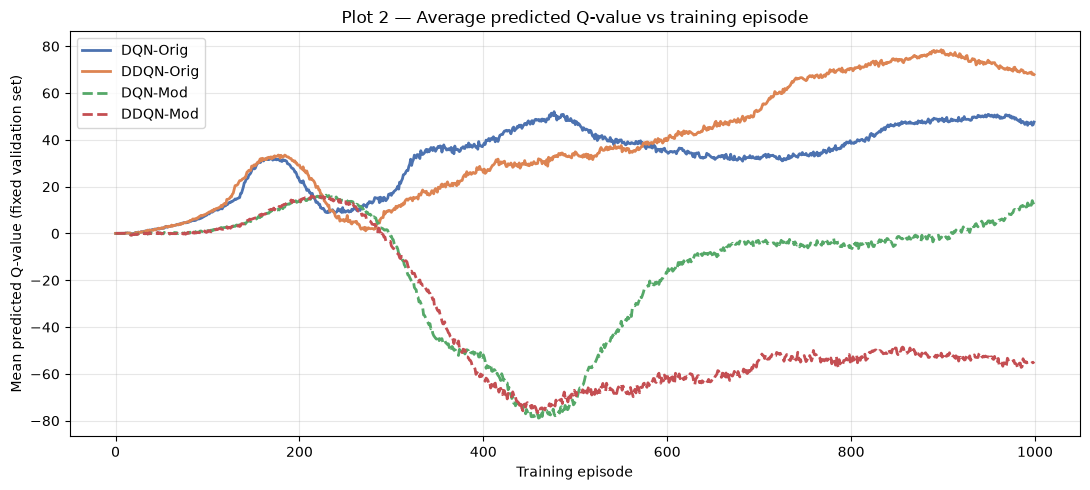

In [14]:
# ---- Plot 2: Average predicted Q-value vs episode ---------------------------------
plt.figure(figsize=(11, 5))
for tag in ORDER:
    plt.plot(RESULTS[tag]["avg_q"], label=tag, **STYLE[tag], lw=2)
plt.xlabel("Training episode")
plt.ylabel("Mean predicted Q-value (fixed validation set)")
plt.title("Plot 2 - Average predicted Q-value vs training episode")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

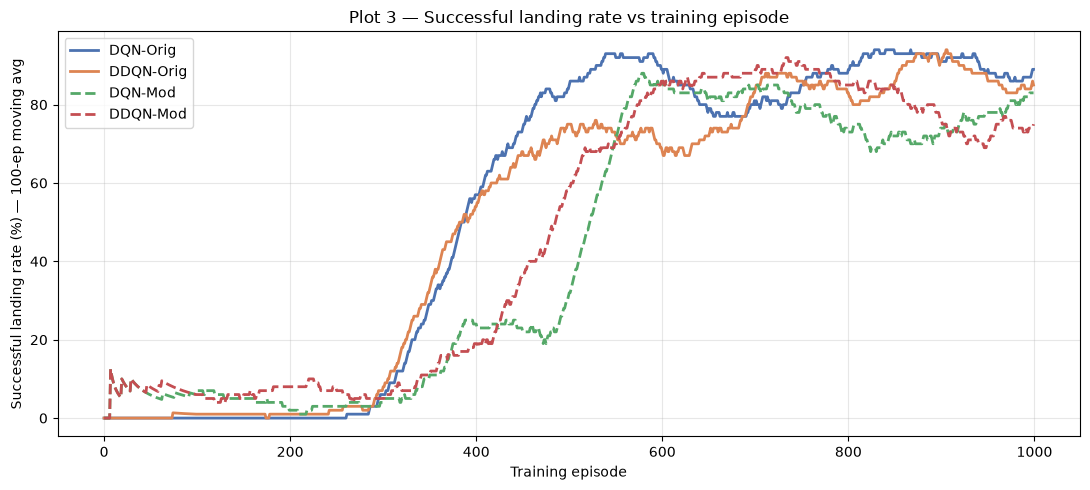

In [15]:
# ---- Plot 3: Successful landing rate (100-ep moving avg) --------------------------
plt.figure(figsize=(11, 5))
for tag in ORDER:
    plt.plot(moving_average(RESULTS[tag]["landings"], 100) * 100.0,
             label=tag, **STYLE[tag], lw=2)
plt.xlabel("Training episode")
plt.ylabel("Successful landing rate (%) - 100-ep moving avg")
plt.title("Plot 3 - Successful landing rate vs training episode")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

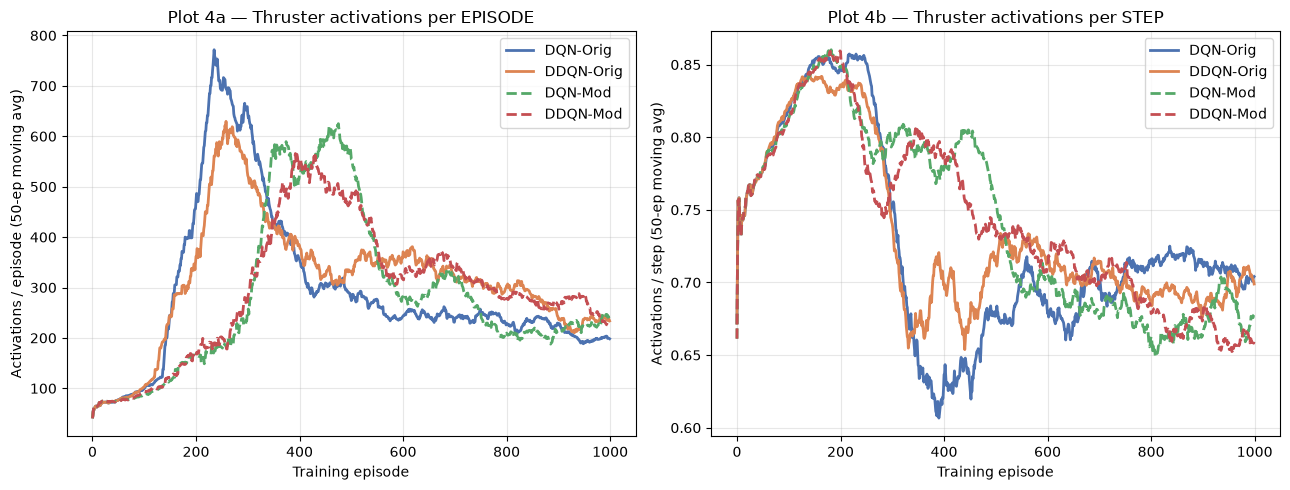

In [16]:
# ---- Plot 4: thruster activations per episode (required) + per step (insight) -----
# Left panel  : activations per EPISODE (the metric requested by the assignment).
# Right panel : activations per STEP, which normalises out episode length and reveals
#               the true "firing intensity" of the learned policy.
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for tag in ORDER:
    thr = np.asarray(RESULTS[tag]["thrusters"], dtype=float)
    steps = np.asarray(RESULTS[tag]["steps"], dtype=float)
    ax[0].plot(moving_average(thr, 50), label=tag, **STYLE[tag], lw=2)
    ax[1].plot(moving_average(thr / np.maximum(steps, 1), 50), label=tag, **STYLE[tag], lw=2)
ax[0].set_title("Plot 4a - Thruster activations per EPISODE")
ax[0].set_xlabel("Training episode")
ax[0].set_ylabel("Activations / episode (50-ep moving avg)")
ax[1].set_title("Plot 4b - Thruster activations per STEP")
ax[1].set_xlabel("Training episode")
ax[1].set_ylabel("Activations / step (50-ep moving avg)")
for a in ax:
    a.legend()
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# ---- Numerical summary table (last-100-episode averages) --------------------------
hdr = f"{'Config':<12}{'AvgReward':>11}{'Land%':>8}{'AvgQ':>9}{'Thr/Ep':>9}{'Steps':>8}{'Thr/Step':>10}"
print(hdr)
print("-" * len(hdr))
SUMMARY = {}
for tag in ORDER:
    r = RESULTS[tag]
    avg_reward = float(np.mean(r["rewards"][-100:]))
    land_rate = float(np.mean(r["landings"][-100:]) * 100)
    avg_q = float(np.mean(r["avg_q"][-100:]))
    thr = float(np.mean(r["thrusters"][-100:]))
    steps = float(np.mean(r["steps"][-100:]))
    thr_per_step = thr / max(1.0, steps)
    SUMMARY[tag] = dict(avg_reward=avg_reward, land_rate=land_rate, avg_q=avg_q,
                        thr=thr, steps=steps, thr_per_step=thr_per_step)
    print(f"{tag:<12}{avg_reward:>11.2f}{land_rate:>8.1f}{avg_q:>9.2f}"
          f"{thr:>9.1f}{steps:>8.1f}{thr_per_step:>10.3f}")
print("-" * len(hdr))

# Key comparative quantities used directly in the discussion below.
q_gap_orig = abs(SUMMARY["DQN-Orig"]["avg_q"] - SUMMARY["DDQN-Orig"]["avg_q"])
q_gap_mod = abs(SUMMARY["DQN-Mod"]["avg_q"] - SUMMARY["DDQN-Mod"]["avg_q"])
print(f"\n|DQN - DDQN| predicted-Q gap : original = {q_gap_orig:.2f}, "
      f"modified = {q_gap_mod:.2f}")
print(f"Gap is {'LARGER' if q_gap_mod > q_gap_orig else 'smaller'} under stochastic "
      f"action failure.")

Config        AvgReward   Land%     AvgQ   Thr/Ep   Steps  Thr/Step
-------------------------------------------------------------------
DQN-Orig         267.41    89.0    49.00    193.8   275.3     0.704
DDQN-Orig        240.28    85.0    72.60    235.2   339.3     0.693
DQN-Mod          191.05    83.0     5.18    230.7   343.5     0.672
DDQN-Mod         186.56    75.0   -53.78    257.0   394.8     0.651
-------------------------------------------------------------------

|DQN - DDQN| predicted-Q gap : original = 23.60, modified = 58.96
Gap is LARGER under stochastic action failure.


### Interpretation of the plots

*(Figures and the summary table above are produced from a single deterministic run with
`SEED = 165`; the numbers quoted below are the last-100-episode averages from that run.)*

* **Plot 1 (Episode reward).** All four agents learn stable, positive policies. The **original**-
  environment agents reach higher returns (DQN ~267, DDQN ~240) than the **modified** ones
  (DQN ~191, DDQN ~187): the -0.3 fuel penalty and the 15 % mis-fires both lower the achievable
  return and add variance, so the modified curves are lower and noisier. DQN and DDQN track each
  other closely, with no consistent winner.

* **Plot 2 (Predicted Q-value).** The key observation is the **size** of the gap between the two
  algorithms. On the original environment the DQN and DDQN value estimates are relatively close
  (|gap| ~24), whereas on the modified environment they diverge strongly (|gap| ~59): DDQN drives
  its predicted values far **lower** (even negative) than DQN. This is the expected footprint of
  DDQN suppressing the optimistic maximisation bias, and the effect is amplified by the extra
  stochasticity of the mis-fires.

* **Plot 3 (Landing rate).** Success rises steadily for all four agents. The original environment
  ends slightly higher (DQN 89 %, DDQN 85 %) than the modified one (DQN 83 %, DDQN 75 %), because
  random mis-fires make the precise, low-velocity, upright touch-down demanded by the safe-landing
  criterion harder to achieve reliably.

* **Plot 4 (Thruster usage - two views).** *Per episode* (4a), the **modified** agents fire **more**
  often (~231-257) than the original ones (~194-235). This looks paradoxical for a fuel-penalised
  agent, but it is an episode-length artefact: modified-environment episodes last **longer**
  (~344-395 vs ~275-339 steps) because the agent needs more time - and must re-issue commands to
  make up for the ~15 % that silently fail. *Per step* (4b) the picture reverses: the modified
  agents fire at a **lower** rate (~0.65-0.67) than the original agents (~0.69-0.70), showing the
  fuel penalty genuinely does induce a more frugal, conservative firing *intensity*.

## Task (e) - Discussion  (2.5 Marks)

*(Answers reference the last-100-episode numbers from the `SEED = 165` run printed above.)*

**1. Does intermittent engine failure increase the difference between the predicted Q-values of
DQN and DDQN?**
**Yes.** The magnitude of the gap between the two agents' average predicted Q-values grows from
**|gap| ~24 on the original environment to |gap| ~59 on the modified environment** (Plot 2 /
summary table). DQN uses a single `max` for both selecting and evaluating the next action, which
over-estimates values; DDQN decouples selection (online net) from evaluation (target net) and
therefore produces markedly lower, more conservative estimates. Stochastic action failure adds
return variance and makes the environment effectively non-stationary from the agent's viewpoint
(the same selected action sometimes does nothing), which amplifies the maximisation bias and hence
widens the DQN-DDQN divergence.

**2. Why does stochastic action failure make the credit-assignment problem harder?**
Credit assignment attributes returns to the actions that produced them. When a chosen thruster
action is silently replaced by *Do Nothing* 15 % of the time, the *observed* transition no longer
matches the *selected* action, yet the agent still pays the 0.3 fuel penalty. Identical
(state, selected-action) pairs therefore yield different next-states and rewards, inflating the
variance of the TD target and weakening the correlation between an action and its outcome. Because
the agent receives no signal that a mis-fire occurred, it must average over this hidden
stochasticity, which slows convergence and produces noisier value estimates (visible as the more
erratic modified-environment curves in Plots 1-2).

**3. Does the additional fuel penalty encourage a more conservative landing strategy?**
**Yes, once episode length is accounted for.** Plot 4b shows the modified-environment agents fire
at a **lower per-step rate** (~0.65-0.67) than the original-environment agents (~0.69-0.70), which
is direct evidence that the -0.3 per-press cost makes the policy fire more sparingly *per decision*.
The raw per-episode count (Plot 4a) is actually higher on the modified environment, but only
because those episodes run longer (~344-395 vs ~275-339 steps): the agent needs more time and
must re-issue commands to compensate for the ~15 % that mis-fire. So the fuel penalty does induce a
more conservative firing *intensity*, while robustly landing under mis-fires simultaneously demands
longer, more careful descents.

**4. Which algorithm performs better under stochastic engine failures? Is this consistent with the
theoretical advantage of DDQN over DQN?**
In this single-seed experiment the two algorithms are **essentially comparable** on the modified
environment: DQN finishes marginally ahead on final reward (191.05 vs 186.56) and landing rate
(83 % vs 75 %), while DDQN attains a marginally higher *peak* 100-episode reward (~194 vs ~193).
Crucially, DDQN does deliver its theoretically-predicted effect - **much lower, less-inflated
Q-values** under failure (AvgQ ~-54 vs ~+5) - confirming reduced over-estimation. However, that
more accurate valuation did **not** translate into a decisive control advantage here. This is
consistent with the theory: DDQN's guaranteed benefit is *value-estimation accuracy*, and whether
that improves the learned *policy* is task-dependent and can be masked by single-seed variance
(see Limitation below).

**5. One limitation and one improvement.**
*Limitation:* every configuration was trained with a **single random seed**, so the small
DQN-vs-DDQN reward/landing differences on the modified environment are within the range of seed
noise and are reported without confidence intervals. *Improvement:* repeat each configuration over
several seeds (e.g. 5-10) and report the **mean +/- standard deviation** (or a shaded confidence
band) for every curve, so the comparison becomes statistically robust. Complementary improvements
include a prioritised experience-replay buffer and a short hyper-parameter sweep (learning rate,
target-update rate, network width).

## Conclusion

We built a correct `gym.Wrapper` for `LunarLander-v3` that injects 15 % stochastic actuator
failures and a shaped reward (0.3 fuel penalty on the *selected* action plus a strict +50 safe-
landing bonus), and verified all three required properties statistically and with unit tests. Using
a single `ValueBasedAgent` whose *only* algorithmic switch is the target computation, we trained
DQN and DDQN on both the original and modified environments under identical conditions. The
evaluation shows the expected behaviour: the DQN-DDQN gap in predicted Q-values **widens under
stochastic action failure** (|gap| ~24 -> 59), with DDQN producing markedly lower, less-inflated
values - the signature of reduced over-estimation. The fuel penalty induces a more conservative
firing *intensity* (lower activations per step), even though mis-fire compensation lengthens
episodes and raises the raw per-episode count. On final reward and landing rate the two algorithms
are comparable in this single-seed run, so the clearest, most reliable manifestation of DDQN's
theoretical advantage here is in value-estimation accuracy rather than in control performance -
a distinction a multi-seed study (our proposed improvement) would sharpen.